# UV_Smooth Pipeline: Input/Output Demonstration

This notebook demonstrates the data transformation through each stage of the `uv_smooth` image reconstruction pipeline.

## Pipeline Overview

```
Sparse Visibilities (N irregular points)
    ↓ Stage 1: Grid Configuration
Parameters: pixel_size, grid_size
    ↓ Stage 2: RBF Interpolation
Regular Grid (260-450 × 260-450 complex)
    ↓ Stage 3: Sinc Interpolation
Final Grid (128 × 128 complex)
    ↓ Stage 4: Landweber Iterations
Reconstructed Image (128 × 128 real)
```

In [1]:
import astropy.units as apu
import numpy as np
import matplotlib.pyplot as plt

from typing import NamedTuple

from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d.art3d import Line3DCollection

from xrayvision.imaging import vis_to_image, get_weights
from xrayvision.transform import idft_map
from xrayvision.uv_smooth import determine_grid_parameters, interpolate_visibilities_to_grid, \
    _sinc_interpolate_to_final_grid, landweber_iteration, uv_smooth_new

from xrayvision.simulation.instruments import rhessi_like_uv_coverage
# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

## Create Mock Visibility Data

We'll create synthetic visibility data that simulates a simple point source with sparse UV coverage.

In [2]:
# Mock Visibilities class
class MockVisibilities(NamedTuple):
    u: np.ndarray
    v: np.ndarray
    visibilities: np.ndarray
    meta: dict

# Generate sparse UV points (simulating interferometer baselines)
u, v, isc  = rhessi_like_uv_coverage().values()

# Simulate visibility data for a simple centered Gaussian source
flux = 100.0  # ph/cm^2/s
sigma = 5.0 * apu.arcsec

# V(u,v) = flux * exp(-2π²σ²(u²+v²))  [source at origin, so no phase term]
vis_vals = flux * np.exp(-2 * np.pi**2 * sigma**2 * (u**2 + v**2))


# Create mock visibilities object (ISC=2 for 320x320 grid)
vis = MockVisibilities(
    u=u.flatten(),
    v=v.flatten(),
    visibilities=vis_vals.flatten(),
    meta={"isc": isc.flatten()}
)

print(f"Created mock visibility data:")
print(f"  Number of measurements: {vis.u.size}")
print(f"  UV range: ({vis.u.min():.3f}, {vis.u.max():.3f}) × ({vis.v.min():.3f}, {vis.v.max():.3f})")
print(f"  Max spatial freq: {np.sqrt(vis.u**2 + vis.v**2).max():.3f}")
print(f"  Detector ISC: {np.unique(vis.meta['isc'])}")

Created mock visibility data:
  Number of measurements: 288
  UV range: (-0.442 1 / arcsec, 0.442 1 / arcsec) × (-0.442 1 / arcsec, 0.442 1 / arcsec)
  Max spatial freq: 0.442 1 / arcsec
  Detector ISC: [0. 1. 2. 3. 4. 5. 6. 7. 8.]


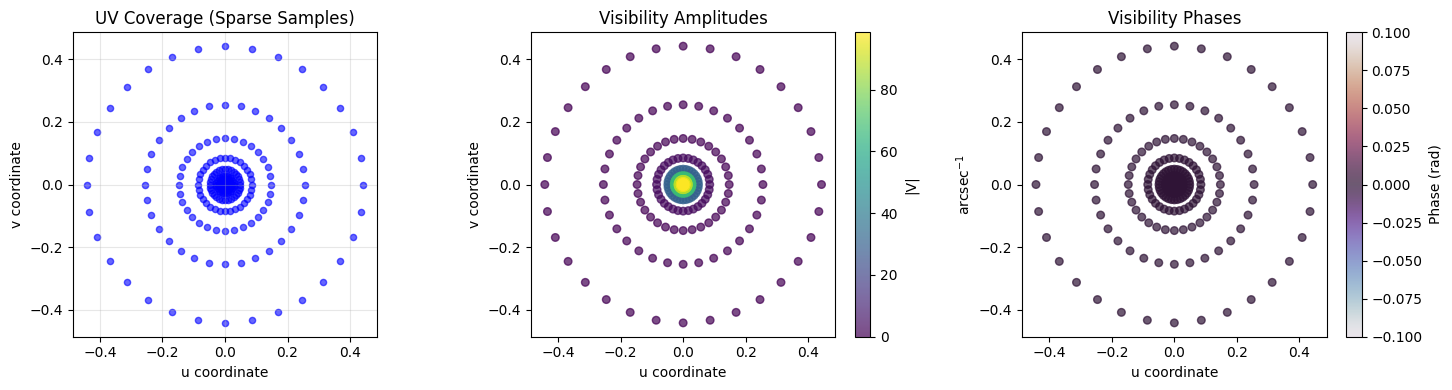


INPUT DATA PROPERTIES:
  Shape: (288,) irregular points
  Data type: u, v → float64, visibilities → complex128
  Memory: ~6.8 KB


In [3]:
with quantity_support():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot UV coverage
    axes[0].scatter(vis.u, vis.v, c='blue', alpha=0.6, s=20)
    axes[0].set_xlabel('u coordinate')
    axes[0].set_ylabel('v coordinate')
    axes[0].set_title('UV Coverage (Sparse Samples)')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)

    # Plot visibility amplitudes
    scatter = axes[1].scatter(vis.u, vis.v, c=np.abs(vis.visibilities),
                              cmap='viridis', alpha=0.7, s=30)
    axes[1].set_xlabel('u coordinate')
    axes[1].set_ylabel('v coordinate')
    axes[1].set_title('Visibility Amplitudes')
    axes[1].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[1], label='|V|')

    # # Plot visibility phases
    scatter = axes[2].scatter(vis.u, vis.v, c=np.angle(vis.visibilities.value),
                              cmap='twilight', alpha=0.7, s=30)
    axes[2].set_xlabel('u coordinate')
    # axes[2].set_ylabel('v coordinate')
    axes[2].set_title('Visibility Phases')
    axes[2].set_aspect('equal')
    plt.colorbar(scatter, ax=axes[2], label='Phase (rad)')

    plt.tight_layout()
    plt.show()

print("\nINPUT DATA PROPERTIES:")
print(f"  Shape: ({len(vis.u)},) irregular points")
print(f"  Data type: u, v → float64, visibilities → complex128")
print(f"  Memory: ~{(vis.u.nbytes + vis.v.nbytes + vis.visibilities.nbytes) / 1024:.1f} KB")

## INPUT: Sparse Visibility Data

Visualize the input data - sparse measurements in UV space.

---

## STAGE 1: Grid Configuration

Determine grid parameters based on detector configuration.

In [4]:
# Stage 1: Determine grid parameters
padded_grid_size, grid_size, uv_pixel_size = determine_grid_parameters(shape=128, pixel_size=1, PADDING_FACTOR=6, DOWNSAMPLE_FACTOR=15)
max_uv = np.sqrt(vis.u**2 + vis.v**2).max()

print("STAGE 1 OUTPUT:")
print(f"  pixel_size: {uv_pixel_size}")
print(f"  grid_size: {grid_size}")
print(f"  padded grid size: {padded_grid_size}")
print(f"  max spatial freq: {max_uv:.4f}")
print(f"\n  → Will create {grid_size}×{grid_size} regular grid")
print(f"  → UV range: ±{(grid_size/2 - 1) * uv_pixel_size + uv_pixel_size/2:.3f}")

STAGE 1 OUTPUT:
  pixel_size: 0.0005208333333333333
  grid_size: 320
  padded grid size: 1920
  max spatial freq: 0.4425 1 / arcsec

  → Will create 320×320 regular grid
  → UV range: ±0.083


---

## STAGE 2: RBF Interpolation to Regular Grid

Transform sparse measurements onto a regular Cartesian grid using Radial Basis Function interpolation.

In [32]:
# Stage 2: Interpolate to regular grid
# Construct regular UV grid for interpolation
uv_limit = (grid_size / 2 - 1) * uv_pixel_size + uv_pixel_size / 2
uv_sample_coords = -uv_limit + np.arange(grid_size) * uv_pixel_size
uu_grid, vv_grid = np.meshgrid(uv_sample_coords, uv_sample_coords)

mask = np.sqrt(uu_grid**2 + vv_grid**2) > max_uv.value
kernels = ['linear', 'cubic', 'quintic', 'thin_plate_spline']
vis_gridded_kernels = {}
for kernel in kernels:
    vis_grid = interpolate_visibilities_to_grid(vis.u, vis.v, vis.visibilities,
                                                uu_grid, vv_grid, kernel=kernel)
    vis_grid[mask] = 0j
    vis_gridded_kernels[kernel] = vis_grid

# pixel_size = 1/(320 * uv_pixel_size)
# images = {}
# for kernel, vis_interp in vis_gridded_kernels.items():
#     cvis = MockVisibilities(u=uu_grid.flatten()/apu.arcsec, v=vv_grid.flatten()/apu.arcsec, visibilities=vis_interp.flatten()*vis.visibilities.unit, meta=vis.meta)
#     image = vis_to_image(cvis, shape=[320,320]*apu.pixel, pixel_size=[pixel_size,pixel_size]*apu.arcsec/apu.pixel)
#     images[kernel] = image


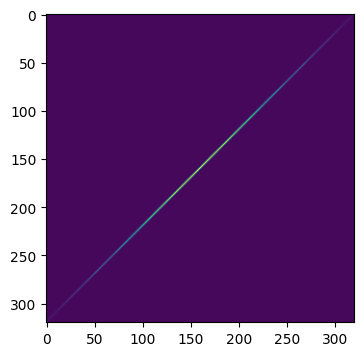

np.complex128(2.5293792432299895+0j)

In [33]:
from numpy.fft import ifft2, ifftshift, fftshift

# plt.imshow(ifft2(fftshift(vis_gridded_kernels['thin_plate_spline'])).imag)
plt.imshow(idft_map(vis_gridded_kernels['linear'], u=uu_grid/apu.arcsec,
                    v=vv_grid/apu.arcsec, shape=[320]*2*apu.pixel,
                    pixel_size=[6]*2*apu.arcsec/apu.pixel))
plt.show()

vis_gridded_kernels['linear'].max()

STAGE 2 OUTPUT:
  Shape: (320, 320)
  Data type: complex128
  Memory: 1.56 MB
  Non-zero elements: 102,400 / 102,400 (100.0%)
  Value range: [0.000, 2.532]


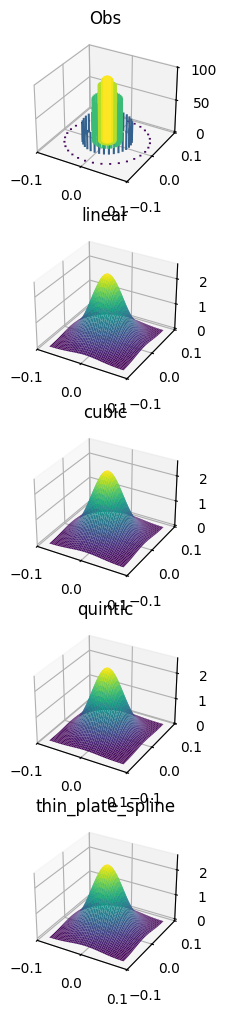

In [7]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(511, projection='3d', title='Obs')
segments = [ [(ui, vi, 0), (ui, vi, zi)] for ui, vi, zi in zip(vis.u.value, vis.v.value, vis.visibilities.real) ]
lc = Line3DCollection(segments, cmap='viridis')
lc.set_array(vis.visibilities.real.value) # Color them based on the z values
ax.add_collection3d(lc)
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(-0.1, 0.1)

for i,  (name, vis_interp) in enumerate(vis_gridded_kernels.items()):
    ax = fig.add_subplot(5, 1, i+2, projection='3d', title=name)
    ax.plot_surface(uu_grid, vv_grid, vis_interp.real, cmap='viridis')
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.1, 0.1)

    # ax = fig.add_subplot(5, 2, 2*i+2)
    # ax.imshow(images[name])

plt.tight_layout()

vis_gridded = vis_gridded_kernels['thin_plate_spline']
vis_gridded[np.sqrt(uu_grid**2 + vv_grid**2) > max_uv.value] = 0j

print("STAGE 2 OUTPUT:")
print(f"  Shape: {vis_gridded.shape}")
print(f"  Data type: {vis_gridded.dtype}")
print(f"  Memory: {vis_gridded.nbytes / (1024**2):.2f} MB")
print(f"  Non-zero elements: {np.count_nonzero(vis_gridded):,} / {vis_gridded.size:,} ({100*np.count_nonzero(vis_gridded)/vis_gridded.size:.1f}%)")
print(f"  Value range: [{np.abs(vis_gridded[vis_gridded != 0]).min():.3f}, {np.abs(vis_gridded).max():.3f}]")

In [ ]:
# Visualize gridded visibilities
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Amplitude
im0 = axes[0].imshow(np.abs(vis_gridded), cmap='viridis', origin='lower',
                     extent=[-uv_limit, uv_limit, -uv_limit, uv_limit])
axes[0].set_title(f'Gridded Visibility Amplitude ({grid_size}×{grid_size})')
axes[0].set_xlabel('u')
axes[0].set_ylabel('v')
plt.colorbar(im0, ax=axes[0], label='|V|')

# Real part
im1 = axes[1].imshow(vis_gridded.real, cmap='RdBu_r', origin='lower',
                     extent=[-uv_limit, uv_limit, -uv_limit, uv_limit])
axes[1].set_title('Real Part')
axes[1].set_xlabel('u')
axes[1].set_ylabel('v')
plt.colorbar(im1, ax=axes[1], label='Re(V)')

# Imaginary part
im2 = axes[2].imshow(vis_gridded.imag, cmap='RdBu_r', origin='lower',
                     extent=[-uv_limit, uv_limit, -uv_limit, uv_limit])
axes[2].set_title('Imaginary Part')
axes[2].set_xlabel('u')
axes[2].set_ylabel('v')
plt.colorbar(im2, ax=axes[2], label='Im(V)')

plt.tight_layout()
plt.show()

---

## STAGE 3: Sinc Interpolation to Final Grid

Resample to final 128×128 grid using sinc interpolation (implemented via zero-padding + centered downsampling).

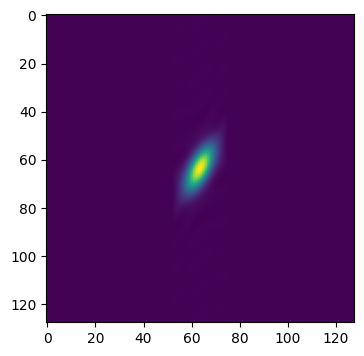


STAGE 3 OUTPUT (Downsampled):
  Shape: (128, 128)
  Data type: complex128
  Memory: 256.00 KB
  Coordinate range: x ∈ [-0.496, 0.496]
                    y ∈ [-0.496, 0.496]
  Value range: [0.000, 2.532]


In [34]:
# Stage 3: Sinc interpolation
vis_downsampled, x_coords_downsampled, y_coords_downsampled, delta_omega, pixel_size = _sinc_interpolate_to_final_grid(
    vis_gridded, grid_size, uv_pixel_size, padded_grid_size)


x_grid, y_grid = np.meshgrid(x_coords_downsampled, y_coords_downsampled)
plt.imshow(idft_map(vis_downsampled, u=x_grid/apu.arcsec,
                    v=y_grid/apu.arcsec, shape=[128]*2*apu.pixel,
                    pixel_size=[pixel_size]*2*apu.arcsec/apu.pixel))
plt.show()


print("\nSTAGE 3 OUTPUT (Downsampled):")
print(f"  Shape: {vis_downsampled.shape}")
print(f"  Data type: {vis_downsampled.dtype}")
print(f"  Memory: {vis_downsampled.nbytes / 1024:.2f} KB")
print(f"  Coordinate range: x ∈ [{x_coords_downsampled.min():.3f}, {x_coords_downsampled.max():.3f}]")
print(f"                    y ∈ [{y_coords_downsampled.min():.3f}, {y_coords_downsampled.max():.3f}]")
print(f"  Value range: [{np.abs(vis_gridded[vis_gridded != 0]).min():.3f}, {np.abs(vis_gridded).max():.3f}]")

In [ ]:
# Visualize the transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original gridded
im0 = axes[0].imshow(np.abs(vis_gridded), cmap='viridis', origin='lower')
axes[0].set_title(f'Before: Gridded ({grid_size}×{grid_size})')
axes[0].set_xlabel('Grid index')
axes[0].set_ylabel('Grid index')
plt.colorbar(im0, ax=axes[0], label='|V|')

# Zero-padded (center region)
# center_slice = slice(896-50, 896+50)  # Show center region
# im1 = axes[1].imshow(np.abs(vis_padded[center_slice, center_slice]),
#                      cmap='viridis', origin='lower')
# axes[1].set_title(f'Intermediate: Zero-Padded (1920×1920, showing center)')
# axes[1].set_xlabel('Grid index')
# axes[1].set_ylabel('Grid index')
# plt.colorbar(im1, ax=axes[1], label='|V|')

# Final downsampled
im2 = axes[2].imshow(np.abs(vis_downsampled), cmap='viridis', origin='lower')
axes[2].set_title(f'After: Sinc Interpolated (128×128)')
axes[2].set_xlabel('Grid index')
axes[2].set_ylabel('Grid index')
plt.colorbar(im2, ax=axes[2], label='|V|')

plt.tight_layout()
plt.show()

---

## STAGE 4: Landweber Iterations (Simplified Demo)

For demonstration, we'll run a few Landweber iterations to show the reconstruction process.

In [ ]:
# Create UV coverage mask
x_grid, y_grid = np.meshgrid(x_coords_downsampled, y_coords_downsampled)
uv_coverage_mask = np.zeros((128, 128), dtype=np.complex128)
uv_coverage_mask[np.sqrt(x_grid**2 + y_grid**2) < max_uv.value] = 1 + 0j

print("UV Coverage Mask:")
print(f"  Shape: {uv_coverage_mask.shape}")
print(f"  Coverage: {np.count_nonzero(uv_coverage_mask)} / {uv_coverage_mask.size} pixels ({100*np.count_nonzero(uv_coverage_mask)/uv_coverage_mask.size:.1f}%)")

# Visualize mask
plt.figure(figsize=(6, 5))
plt.imshow(uv_coverage_mask.real, cmap='binary', origin='lower')
plt.title('UV Coverage Mask (χ)')
plt.xlabel('Grid index')
plt.ylabel('Grid index')
plt.colorbar(label='Mask value')
plt.tight_layout()
plt.show()

In [ ]:
# Run simplified Landweber iterations

final_image, fourier_transform = landweber_iteration(vis_downsampled, vis_downsampled.shape[0], uv_coverage_mask, delta_omega)

# print(f"\nSTAGE 4 OUTPUT (after {n_demo_iterations} iterations):")
print(f"  Shape: {final_image.shape}")
print(f"  Data type: {final_image.dtype}")
print(f"  Memory: {final_image.nbytes / 1024:.2f} KB")
print(f"  Value range: [{final_image.min():.3e}, {final_image.max():.3e}]")
# print(f"  Final residual norm: {residual_norms[-1]:.3e}")

In [ ]:
# Visualize convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual convergence
# axes[0].plot(residual_norms, 'b-', linewidth=2)
# axes[0].set_xlabel('Iteration')
# axes[0].set_ylabel('Residual Norm ||χ·F - V||')
# axes[0].set_title('Convergence of Landweber Iterations')
# axes[0].grid(True, alpha=0.3)
# axes[0].set_yscale('log')

# Descent rate
descent_rates = []
for i in range(1, len(residual_norms)):
    descent = (residual_norms[i-1] - residual_norms[i]) / residual_norms[i-1]
    descent_rates.append(descent)

axes[1].plot(descent_rates, 'r-', linewidth=2)
axes[1].axhline(0.02, color='green', linestyle='--', label='Convergence threshold (2%)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Descent Rate')
axes[1].set_title('Relative Change in Residual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Show image evolution
iterations_to_show = [0, 4, 9, 19]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, iter_num in enumerate(iterations_to_show):
    im = axes[idx].imshow(iteration_images[iter_num], cmap='hot', origin='lower')
    axes[idx].set_title(f'Iteration {iter_num + 1}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    plt.colorbar(im, ax=axes[idx], label='Intensity')

plt.suptitle('Image Evolution During Landweber Iterations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## OUTPUT: Final Reconstructed Image

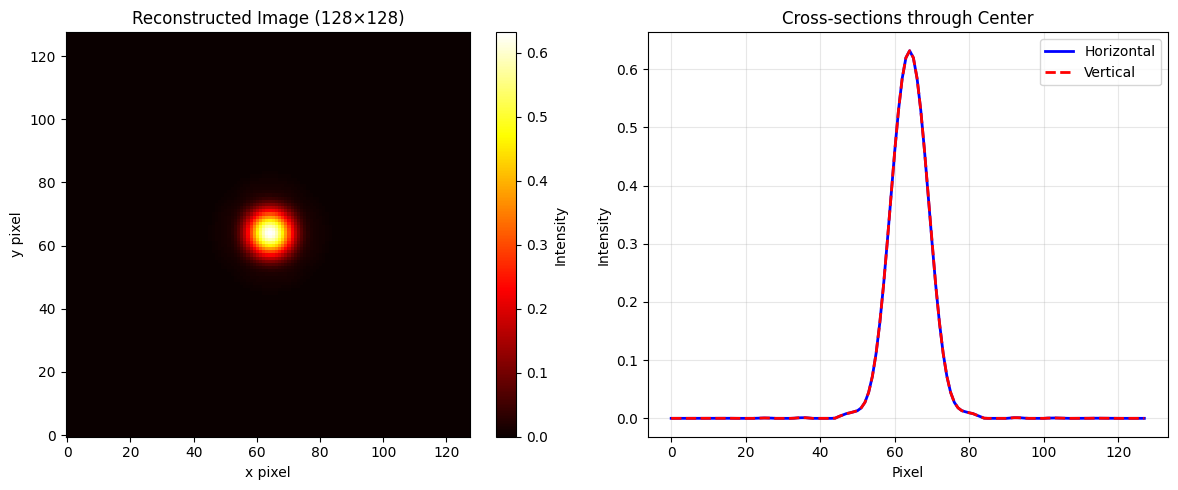


FINAL OUTPUT PROPERTIES:
  Shape: (128, 128)
  Data type: float64
  Value range: [0.000e+00, 6.317e-01]
  Mean: 6.027e-03
  Std: 4.277e-02
  All values ≥ 0: True  (positivity constraint satisfied)


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

final_image, fourier_transform, pixel_size = uv_smooth_new(vis, shape=128, pixel_size=1.0, kernel='linear')

# 2D image
im = axes[0].imshow(final_image, cmap='hot', origin='lower')
axes[0].set_title('Reconstructed Image (128×128)')
axes[0].set_xlabel('x pixel')
axes[0].set_ylabel('y pixel')
plt.colorbar(im, ax=axes[0], label='Intensity')

# Cross-section through center
center_idx = 64
axes[1].plot(final_image[center_idx, :], 'b-', linewidth=2, label='Horizontal')
axes[1].plot(final_image[:, center_idx], 'r--', linewidth=2, label='Vertical')
axes[1].set_xlabel('Pixel')
axes[1].set_ylabel('Intensity')
axes[1].set_title('Cross-sections through Center')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFINAL OUTPUT PROPERTIES:")
print(f"  Shape: {final_image.shape}")
print(f"  Data type: {final_image.dtype}")
print(f"  Value range: [{final_image.min():.3e}, {final_image.max():.3e}]")
print(f"  Mean: {final_image.mean():.3e}")
print(f"  Std: {final_image.std():.3e}")
print(f"  All values ≥ 0: {(final_image >= 0).all()}  (positivity constraint satisfied)")

---

## Summary: Data Transformation Pipeline

| Stage | Input | Output | Transformation |
|-------|-------|--------|----------------|
| **Input** | Raw measurements | N sparse (u,v) points | Irregular sampling |
| **Stage 1** | Detector metadata | pixel_size, grid_size | Configuration |
| **Stage 2** | Sparse visibilities | 260-450 × 260-450 complex | RBF interpolation |
| **Stage 3** | Regular grid | 128 × 128 complex | Sinc interpolation |
| **Stage 4** | Final grid | 128 × 128 real | Landweber + positivity |
| **Output** | Reconstructed image | 128 × 128 real | Physical image |

In [ ]:
# Memory summary
print("MEMORY USAGE SUMMARY:")
print(f"  Input (sparse):        ~{(vis.u.nbytes + vis.v.nbytes + vis.visibilities.nbytes) / 1024:.1f} KB")
print(f"  Stage 2 (gridded):     {vis_gridded.nbytes / (1024**2):.2f} MB")
print(f"  Stage 3 (padded):      {vis_padded.nbytes / (1024**2):.2f} MB  ← Peak memory")
print(f"  Stage 3 (final):       {vis_final.nbytes / 1024:.2f} KB")
print(f"  Output (image):        {final_image.nbytes / 1024:.2f} KB")
print(f"\n  Total peak: ~{vis_padded.nbytes / (1024**2):.1f} MB")